# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 39    |  |
| :-------------|:-------------|
| Faical Abakouy| 5554462|
| Alejandro Jean|6270611|
| Hidde van den Bergh| 6576079 |

| Planning Groep: 39     |Tijdstip / Tijdspanne  |
|---|---|
| commesator gebouwd | 11.45 |
| Sanity check | 12.30 |
| Pauze | 12.45-13.45 |
| gekalibreert|15.00|
| datasheet af|16.30|



## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="schets 3.jpeg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
def Capaciteit(eps0, epsr,A, d):
    return (eps0*epsr*A/d)

def Capaciteit2(R,A_in,A_out, f):
    return A_out/(R*2*np.pi*f*A_in)
print(Capaciteit2(1000,15.16,1.19,100000),"F")
# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

1.2493033131883606e-10 F


In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C = [Capaciteit(3,8.854e-12,0.01,0.001)]


print(f"Berekende capaciteit plaatcondensator groep 39 is {C[0]:.2e} pF")



Berekende capaciteit plaatcondensator groep 39 is 2.66e-10 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](iteratie1.jpeg)
![scope meting 2](scherm.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 39| $2.66e-10 F$ |$2.67 V$ | $1.19 V$ |$1.25e-10 F $ |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](schets1.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

uiteindelijk is er gekozen om de sensor te gebruiken als een krachtsensor voor een weegschaal

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](schets2.jpeg)

In [3]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
def condensator_extra_laag(m, a, b, c):
    D_0 = 0.04 #onbelaste dikte
    d1 = 0.001
    g = 9.81
    eps0 = 8.854e-12
    eps1 = 1.3 #schuim
    eps2 = 2.5 
    A1 = 0.10 * 0.10 #oppervlakte plaat
    F = m * g
    #formule variabele veerconstante (parabool benadering)
    k = a*(F - b)**2 + c
    d2 = D_0 - (F/k)
    C = eps0*((eps1*(d1/(d2+d1)) + eps2*(d2/(d2+d1)))) * A1 / (d1+d2 )
    return C * 1e12

# Deze functie is afgeleid uit de formule  voor de veerkracht: F=k*x.

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 1.5 |7.5 |
| gemiddelde capaciteit| 2.5 |12.6 |
| maximale capaciteit| 4 |20.1 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 2](metingzonder.jpeg)
![meting 1](schermzonder.jpeg)
![meting 1](metingmet.jpeg)
![meting 1](schermmet.jpeg)


## Opdracht 7: Plot de kalibratiegrafiek.

C:\Users\Alejandro\AppData\Local\Temp\ipykernel_8936\2877676090.py:23: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(fitfunc, Farad, massa, maxfev=200000)


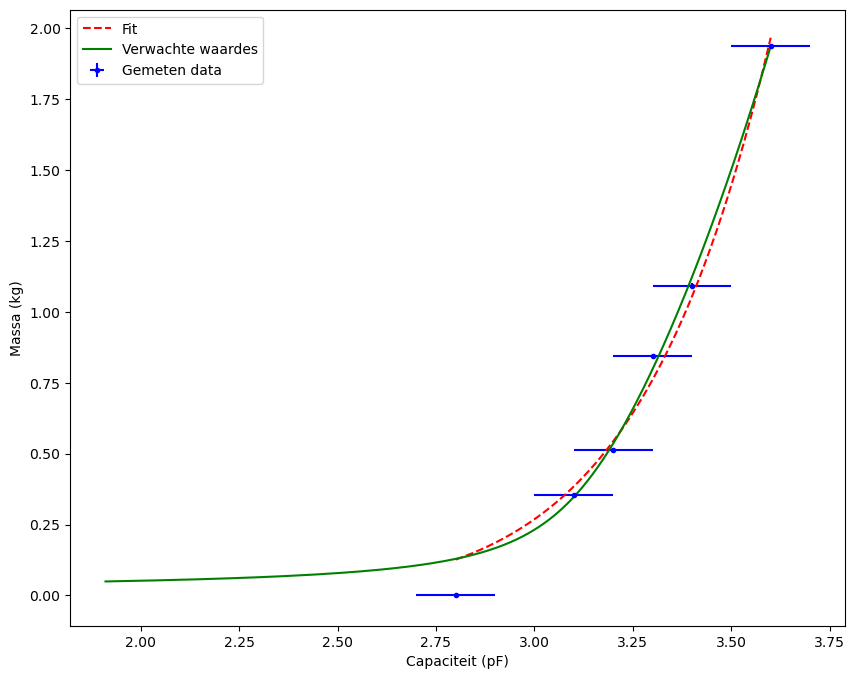

In [4]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
massa = np.array([0, 0.3527, 0.5116, 0.8446, 1.0923, 1.9369])
Farad = np.array([2.8, 3.1, 3.2, 3.3, 3.4, 3.6]) 

def fitfunc(x, a, b, c):
    return a/(x**b)

def condensator_extra_laag(m, a, b, c):
    D_0 = 0.04 #onbelaste dikte
    d1 = 0.001
    g = 9.81
    eps0 = 8.854e-12
    eps1 = 1.3 #schuim
    eps2 = 2.5 
    A1 = 0.10 * 0.10 #oppervlakte plaat
    F = m * g
    #formule variabele veerconstante (parabool benadering)
    k = a*(F - b)**2 + c
    d2 = D_0 - (F/k)
    C = eps0*((eps1*(d1/(d2+d1)) + eps2*(d2/(d2+d1)))) * A1 / (d1+d2 )
    return C * 1e12

popt, pcov = curve_fit(fitfunc, Farad, massa, maxfev=200000)
popt2, pcov2 = curve_fit(condensator_extra_laag, massa, Farad, maxfev=200000)

x2 = np.linspace(np.min(Farad), np.max(Farad), 1000)
x3 = np.linspace(min(massa[1:])*0.14, max(massa), 1000)

plt.figure(figsize=(10,8))
plt.errorbar(Farad, massa, yerr= 0.008, xerr=0.1, fmt='b.', label='Gemeten data')
plt.plot(x2, fitfunc(x2, *popt), 'r--',label='Fit')
plt.plot(condensator_extra_laag(x3, *popt2), x3, 'g-', label='Verwachte waardes')
plt.ylabel('Massa (kg)')
plt.xlabel('Capaciteit (pF)')
plt.legend()
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* Meer schuimlagen, om een grotere d te krijgen.
* Schuimlaag in een plastic zak zetten

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](laatsteiteratie.jpeg)

C:\Users\Alejandro\AppData\Local\Temp\ipykernel_8936\2686521802.py:25: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(fitfunc, Farad, massa, maxfev=200000)


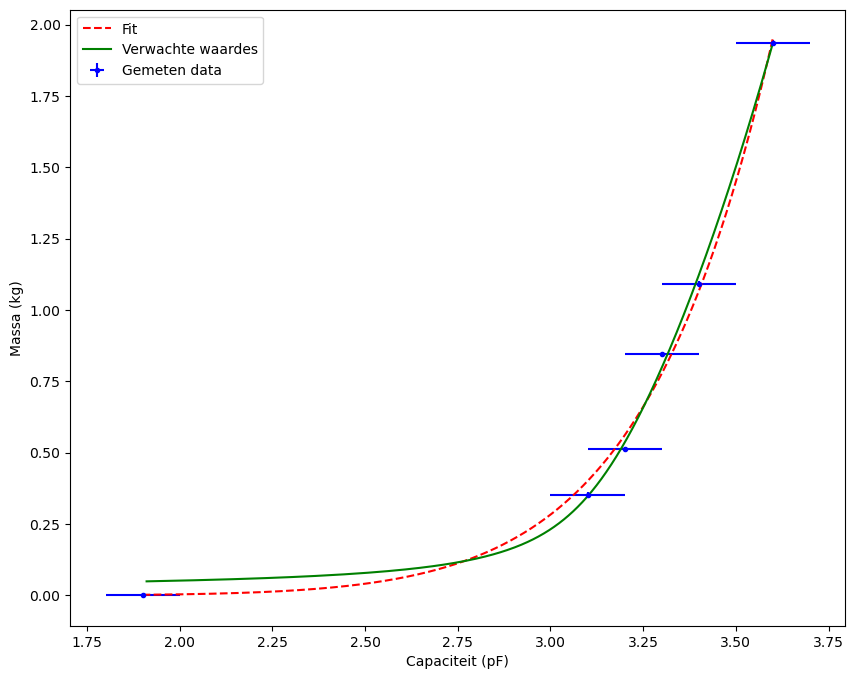

In [5]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
massa = np.array([0, 0.3527, 0.5116, 0.8446, 1.0923, 1.9369])
Farad = np.array([1.9, 3.1, 3.2, 3.3, 3.4, 3.6]) 

def fitfunc(x, a, b, c):
    return a/(x**b)

def condensator_extra_laag(m, a, b, c):
    D_0 = 0.04 #onbelaste dikte
    d1 = 0.001
    g = 9.81
    eps0 = 8.854e-12
    eps1 = 1.3 #schuim
    eps2 = 2.5 
    A1 = 0.10 * 0.10 #oppervlakte plaat
    F = m * g
    #formule variabele veerconstante (parabool benadering)
    k = a*(F - b)**2 + c
    d2 = D_0 - (F/k)
    C = eps0*((eps1*(d1/(d2+d1)) + eps2*(d2/(d2+d1)))) * A1 / (d1+d2 )
    return C * 1e12

popt, pcov = curve_fit(fitfunc, Farad, massa, maxfev=200000)
popt2, pcov2 = curve_fit(condensator_extra_laag, massa, Farad, maxfev=200000)

x2 = np.linspace(np.min(Farad), np.max(Farad), 1000)
x3 = np.linspace(min(massa[1:])*0.14, max(massa), 1000)

plt.figure(figsize=(10,8))
plt.errorbar(Farad, massa, yerr= 0.008, xerr=0.1, fmt='b.', label='Gemeten data')
plt.plot(x2, fitfunc(x2, *popt), 'r--',label='Fit')
plt.plot(condensator_extra_laag(x3, *popt2), x3, 'g-', label='Verwachte waardes')
plt.ylabel('Massa (kg)')
plt.xlabel('Capaciteit (pF)')
plt.legend()
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

Na meerdere iteraties werd er geconcludeerd dat de sensor niet geschikt was voor het wegen van spullen. Het juiste isolatie materiaal voor dit proefje was niet aanwezig en schuime vierkantjes was het meest geschikte wat wij hebben kunnen vinden. Uiteindelijk is de benodigde dikte ook onderschat en is die op de laatste iteratie gevierdubbeld, om metingen preciezer te maken. Na deze veranderingen werkte het mechanisme genoeg om bruikbaar te zijn. De vlakke plaat formule klopt, maar er werd wel lang mee geworsteld. Het verschil tussen de verwachtte waardes en onze fit is te verklaren door de apparatuur rond onze opstelling die invloed had op onze gemeten capaciteit, want de apparatuur had zijn eigen capaciteit die de metingen beinvloedde. Er werd gestreven naar een capaciteit rond de 50 pF omdat dat de onzekerheid relatief klein zou zijn, dit hebben wij niet gehaald waardoor de onzekerheid relatief heel groot is en wat het verschil kan verklaren.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

Leerdoel 1:

In [6]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
def condensator_extra_laag(m, a, b, c):
    D_0 = 0.04 #onbelaste dikte
    d1 = 0.001
    g = 9.81
    eps0 = 8.854e-12
    eps1 = 1.3 #schuim
    eps2 = 2.5 
    A1 = 0.10 * 0.10 #oppervlakte plaat
    F = m * g
    #formule variabele veerconstante (parabool benadering)
    k = a*(F - b)**2 + c
    d2 = D_0 - (F/k)
    C = eps0*((eps1*(d1/(d2+d1)) + eps2*(d2/(d2+d1)))) * A1 / (d1+d2 )
    return C * 1e12

# Deze functie is afgeleid uit de formule  voor de veerkracht: F=k*x.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](schets2.jpeg)

Leerdoel 2:

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 1.5 |7.5 |
| gemiddelde capaciteit| 2.5 |12.6 |
| maximale capaciteit| 4 |20.1 |

Leerdoel 3

C:\Users\Alejandro\AppData\Local\Temp\ipykernel_8936\1146843445.py:23: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(fitfunc, Farad, massa, maxfev=200000)


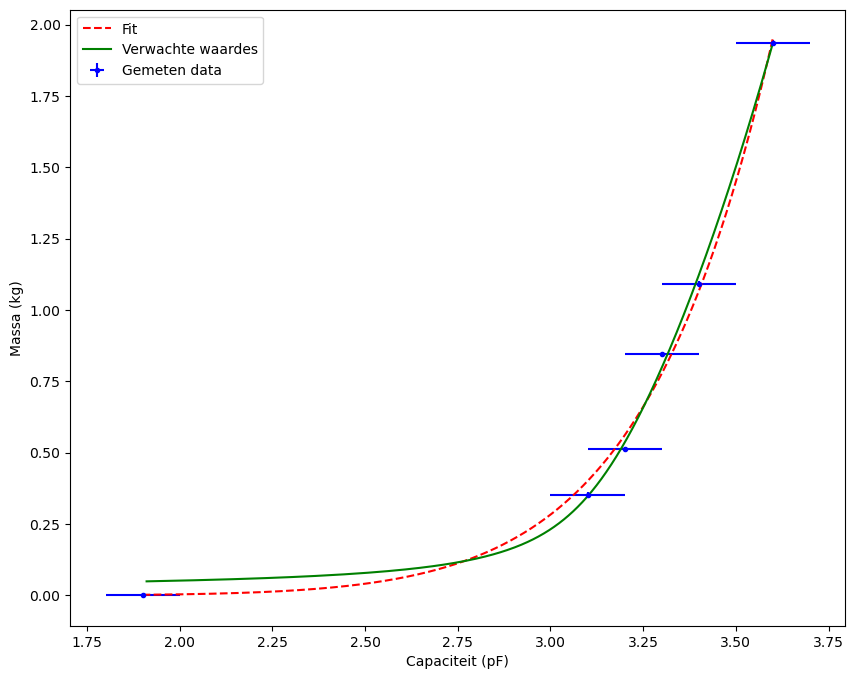

In [7]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
massa = np.array([0, 0.3527, 0.5116, 0.8446, 1.0923, 1.9369])
Farad = np.array([1.9, 3.1, 3.2, 3.3, 3.4, 3.6]) 

def fitfunc(x, a, b, c):
    return a/(x**b)

def condensator_extra_laag(m, a, b, c):
    D_0 = 0.04 #onbelaste dikte
    d1 = 0.001
    g = 9.81
    eps0 = 8.854e-12
    eps1 = 1.3 #schuim
    eps2 = 2.5 
    A1 = 0.10 * 0.10 #oppervlakte plaat
    F = m * g
    #formule variabele veerconstante (parabool benadering)
    k = a*(F - b)**2 + c
    d2 = D_0 - (F/k)
    C = eps0*((eps1*(d1/(d2+d1)) + eps2*(d2/(d2+d1)))) * A1 / (d1+d2 )
    return C * 1e12

popt, pcov = curve_fit(fitfunc, Farad, massa, maxfev=200000)
popt2, pcov2 = curve_fit(condensator_extra_laag, massa, Farad, maxfev=200000)

x2 = np.linspace(np.min(Farad), np.max(Farad), 1000)
x3 = np.linspace(min(massa[1:])*0.14, max(massa), 1000)

plt.figure(figsize=(10,8))
plt.errorbar(Farad, massa, yerr= 0.008, xerr=0.1, fmt='b.', label='Gemeten data')
plt.plot(x2, fitfunc(x2, *popt), 'r--',label='Fit')
plt.plot(condensator_extra_laag(x3, *popt2), x3, 'g-', label='Verwachte waardes')
plt.ylabel('Massa (kg)')
plt.xlabel('Capaciteit (pF)')
plt.legend()
plt.show()

Na meerdere iteraties werd er geconcludeerd dat de sensor niet geschikt was voor het wegen van spullen. Het juiste isolatie materiaal voor dit proefje was niet aanwezig en schuime vierkantjes was het meest geschikte wat wij hebben kunnen vinden. Uiteindelijk is de benodigde dikte ook onderschat en is die op de laatste iteratie gevierdubbeld, om metingen preciezer te maken. Na deze veranderingen werkte het mechanisme genoeg om bruikbaar te zijn. De vlakke plaat formule klopt, maar er werd wel lang mee geworsteld. Het verschil tussen de verwachtte waardes en onze fit is te verklaren door de apparatuur rond onze opstelling die invloed had op onze gemeten capaciteit, want de apparatuur had zijn eigen capaciteit die de metingen beinvloedde. Er werd gestreven naar een capaciteit rond de 50 pF omdat dat de onzekerheid relatief klein zou zijn, dit hebben wij niet gehaald waardoor de onzekerheid relatief heel groot is en wat het verschil kan verklaren.